# G1 — 모델 일반화 셀 (W3 고정)

ResNet18 단일 셀서 본 현상이 **다른 CNN에서도 재현되나**:
- **진단 일반화 ①②**: `normHd2`가 단일층 short recovery를 예측하는가? (부분상관, size 통제)
- **적용 일반화 ⑤**: proxy-guided partial QAT가 적은 param%로 full에 근접하는가?

모델 = ResNet34 · MobileNetV2 (CNN 2 family). 모델별 try/except + incremental 저장. **"현상 재현"이지 "selector recipe 제안" 아님.**

In [1]:
# --- Colab 셋업 ---
import os
REPO = '/content/26_Capstone'
if not os.path.isdir(REPO):
    !git clone -q https://github.com/u-nsiq/26_Capstone.git {REPO}
else:
    !git -C {REPO} pull -q
os.chdir(REPO)
!pip install -q -r requirements.txt
import torch; print('torch', torch.__version__, '| cuda', torch.cuda.is_available())

torch 2.11.0+cu128 | cuda True


In [2]:
# --- 엔진 + Drive + 로더 + 모델 ---
from qat_engine import *
import numpy as np, matplotlib.pyplot as plt, json

try:
    from google.colab import drive; drive.mount('/content/drive')
    ART = '/content/drive/MyDrive/26_Capstone'
except Exception:
    ART = './_local_art'
for sub in ['checkpoints', 'outputs/G1', 'figures']:
    os.makedirs(f'{ART}/{sub}', exist_ok=True)
DATA_ROOT = f'{ART}/data'
OUTDIR = f'{ART}/outputs/G1'
N_BITS = 3

train_loader, val_loader, calib_loader = get_loaders('cifar100', batch=128, calib_size=1024, data_root=DATA_ROOT)

# CIFAR100/W3. ckpt 없으면 train_baseline가 FP 학습(모델별 ~시간 = long pole). ViT는 아래 md 참고.
MODELS = ['resnet34', 'mobilenetv2_100']
print('device', DEVICE, '| models', MODELS)

Mounted at /content/drive
device cuda | models ['resnet34', 'mobilenetv2_100']


In [3]:
# --- G1 실행: 모델별 일반화 셀 (진단①②+적용⑤). 모델별 백업 + try/except ---
# 규모: 단일층 sweep(층수 × seeds × long_t) + payoff. ResNet34~37층, MobileNetV2~52층 → 무거움(GPU 의존).
#   세션 시작 시 !nvidia-smi 확인: A100/L4면 그대로, T4면 ① SEEDS=(0,1)로 ② 두 모델을 두 세션에 분리(MODELS=['resnet34'] / ['mobilenetv2_100']).
#   ⚠ long_t는 800 유지 — long_t↓는 ①inversion(1-ρ(short,long))을 직접 약화('same trend' 아님). 정 빡빡하면 long_t=500까지만.
results = {}
P = f'{OUTDIR}/g1_generalization_w{N_BITS}.json'
SEEDS = (0, 1, 2)        # T4로 마감 빡빡하면 (0, 1)로. inversion 점추정이라 seed는 무해축(long_t와 달리).
for m in MODELS:
    ckpt = f'{ART}/checkpoints/{m}_cifar100_fp32.pt'
    print(f'=== {m} ===  (FP 캐시 없으면 60ep 학습 = long pole)')
    try:
        results[m] = run_generalization_cell(m, train_loader, val_loader, calib_loader, ckpt,
                                             n_bits=N_BITS, B=0.25, short_t=30, long_t=800,
                                             seeds=SEEDS, device=DEVICE)
        json.dump(results[m], open(f'{OUTDIR}/g1_gen_w{N_BITS}_{m}.json', 'w'), indent=2)  # 모델별 백업(세션분할/크래시 안전)
        json.dump(results, open(P, 'w'), indent=2)                                          # 누적 머지
        r = results[m]; fa = r['fp_acc']; pa = r['ptq_acc']; cs = r['corr_short_partN']; iv = r['inv_1mrho']
        print(f'  OK  fp={fa:.2f} ptq={pa:.2f} | nHd2->short partN={cs:+.2f} | inv 1-rho={iv:+.2f} (점추정,CI없음)  (saved)')
    except Exception as e:
        print(f'  FAIL {m}: {type(e).__name__}: {e}')
print('done ->', P)

=== resnet34 ===  (FP 캐시 없으면 60ep 학습 = long pole)
[baseline] epoch 1/60  top1 17.30  best 17.30
[baseline] epoch 2/60  top1 28.35  best 28.35
[baseline] epoch 3/60  top1 32.94  best 32.94
[baseline] epoch 4/60  top1 41.14  best 41.14
[baseline] epoch 5/60  top1 41.41  best 41.41
[baseline] epoch 6/60  top1 45.95  best 45.95
[baseline] epoch 7/60  top1 47.81  best 47.81
[baseline] epoch 8/60  top1 51.92  best 51.92
[baseline] epoch 9/60  top1 52.45  best 52.45
[baseline] epoch 10/60  top1 54.20  best 54.20
[baseline] epoch 11/60  top1 54.43  best 54.43
[baseline] epoch 12/60  top1 55.09  best 55.09
[baseline] epoch 13/60  top1 55.76  best 55.76
[baseline] epoch 14/60  top1 56.14  best 56.14
[baseline] epoch 15/60  top1 55.43  best 56.14
[baseline] epoch 16/60  top1 57.92  best 57.92
[baseline] epoch 17/60  top1 61.36  best 61.36
[baseline] epoch 18/60  top1 61.72  best 61.72
[baseline] epoch 19/60  top1 58.75  best 61.72
[baseline] epoch 20/60  top1 57.60  best 61.72
[baseline] epoch 21

In [4]:
# --- 일반화 표 (진단 corr/inv + 적용 payoff) ---
import glob
def _recast(r):                                   # 재로드 시 JSON str키 → int 복원 (ENG-7)
    p = r['payoff']
    for d in ('R', 'R_std', 'acc'):
        p[d] = {k: {int(t): v for t, v in s.items()} for k, s in p[d].items()}
    p['t_evals'] = [int(t) for t in p['t_evals']]
    r['single_R'] = {L: {int(t): v for t, v in s.items()} for L, s in r['single_R'].items()}
    return r
try: results
except NameError: results = {}
for f in glob.glob(f'{OUTDIR}/g1_gen_w{N_BITS}_*.json'):   # 세션분할 대비: 모델별 백업 병합
    m = f.replace('\\', '/').split(f'g1_gen_w{N_BITS}_')[-1][:-5]
    if m not in results:
        results[m] = _recast(json.load(open(f)))

def recov(acc, ptq, full):
    return 100.0 * (acc - ptq) / (full - ptq) if full > ptq else float('nan')
print('inv = 1-ρ(short,long) 점추정 (S1.2 real_inversion 게이트 미적용 → 정성 신호). recov% = accuracy recovery.')
print('partN* = |ρ|>1.96/√(n-1) 유의 / ~ = 약신호')
print('model         fp     ptq    gap   | nHd2->short inv | nHd2-topk(param%,acc-recov%)  rand(avg)  full')
print('  resnet18*    76.84  63.36  13.48 |   +0.88*    .  | (S1.2/U5 기존 셀; inv@2500=.186)')
for m, r in results.items():
    p5 = r['payoff']; T = r['long_t']
    fa = r['fp_acc']; pa = r['ptq_acc']; g = r['gap']; cs = r['corr_short_partN']; iv = r['inv_1mrho']
    nh_a = p5['acc']['normHd2-topk'][T]; rn_a = p5['acc']['random(avg)'][T]; fl_a = p5['acc']['full'][T]
    nh_p = p5['param_ratio']['normHd2-topk'] * 100; rv = recov(nh_a, pa, fl_a)
    thr = 1.96 / (max(r['n_layers'] - 1, 1)) ** 0.5      # 부분상관 노이즈선 (|ρ|>thr만 유의)
    sig = '*' if abs(cs) > thr else '~'
    print(f'  {m:<12} {fa:5.2f}  {pa:5.2f}  {g:5.2f} |  {cs:+.2f}{sig}   {iv:+.2f} | {nh_a:6.2f}({nh_p:.0f}%,{rv:.0f}%)        {rn_a:6.2f}   {fl_a:6.2f}')

inv = 1-ρ(short,long) 점추정 (S1.2 real_inversion 게이트 미적용 → 정성 신호). recov% = accuracy recovery.
partN* = |ρ|>1.96/√(n-1) 유의 / ~ = 약신호
model         fp     ptq    gap   | nHd2->short inv | nHd2-topk(param%,acc-recov%)  rand(avg)  full
  resnet18*    76.84  63.36  13.48 |   +0.88*    .  | (S1.2/U5 기존 셀; inv@2500=.186)
  resnet34     77.91  70.05   7.86 |  +0.46*   +0.23 |  75.28(25%,93%)         74.97    75.67
  mobilenetv2_100 67.13  43.81  23.32 |  +0.81*   +0.12 |  62.14(25%,111%)         61.25    60.35


/tmp/ipykernel_4578/3953589904.py:13: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(f'{OUTDIR}/g1_proxy_corr.png', dpi=120); plt.show()
/tmp/ipykernel_4578/3953589904.py:13: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(f'{OUTDIR}/g1_proxy_corr.png', dpi=120); plt.show()
/tmp/ipykernel_4578/3953589904.py:13: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(f'{OUTDIR}/g1_proxy_corr.png', dpi=120); plt.show()
/tmp/ipykernel_4578/3953589904.py:13: UserWarning: Glyph 48152 (\N{HANGUL SYLLABLE BAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(f'{OUTDIR}/g1_proxy_corr.png', dpi=120); plt.show()
/tmp/ipykernel_4578/3953589904.py:13: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(f'{OUTDIR

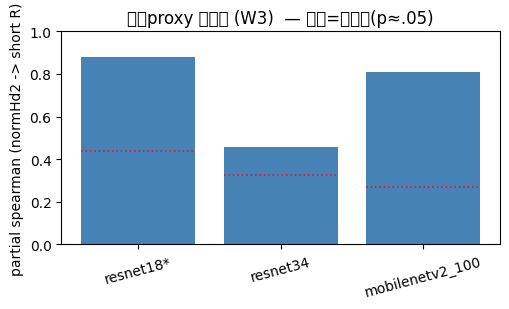

In [5]:
# --- Proxy 일반화 그림: 모델별 normHd2->short 부분상관 (+ 유의 노이즈선) ---
names = ['resnet18*'] + list(results.keys())
corrs = [0.88] + [results[m]['corr_short_partN'] for m in results]
nlay  = [21] + [results[m]['n_layers'] for m in results]
plt.figure(figsize=(5.2, 3.2))
plt.bar(range(len(names)), corrs, color='steelblue'); plt.axhline(0, color='k', lw=0.5)
for i, n in enumerate(nlay):                                  # |ρ|>1.96/√(n-1) 만 유의 (HON-3)
    thr = 1.96 / (max(n - 1, 1)) ** 0.5
    plt.hlines(thr, i - 0.4, i + 0.4, color='crimson', ls=':', lw=1.2)
plt.xticks(range(len(names)), names, rotation=15); plt.ylim(0, 1)
plt.ylabel('partial spearman (normHd2 -> short R)')
plt.title(f'단기proxy 일반화 (W{N_BITS})  — 점선=유의선(p≈.05)')
plt.tight_layout(); plt.savefig(f'{OUTDIR}/g1_proxy_corr.png', dpi=120); plt.show()

## G1 해석 (모델 일반화)

**발표 슬라이드 2장:**
1. **일반화 표** — 모델별 PTQ → partial QAT(normHd2-topk) → full, param%·acc-recovery%
2. **Proxy 일반화 그림** — 모델별 normHd2→short 부분상관 (ResNet18만의 결과 아님)

읽는 법 (메인 셀 S1.2 기준에 맞춰 *조건부*로):
- **`nHd2->short partN`이 양수이고 유의선(`*`, |ρ|>1.96/√(n-1))을 넘으면** → 단기proxy가 다른 CNN서도 회복층 예측 → **진단 일반화**. 작은 양수(`~`)는 *약신호*(✓ 아님).
- **`normHd2-topk`가 적은 param%로 full 근접** → partial QAT payoff 재현 → **적용 일반화**. (random은 U5와 동일 ×3 평균 = `rand(avg)`.)
- **`inv 1-rho` 양수(같은 부호)** → 역전 *신호*가 같은 방향. 단 S1.2의 real_inversion 게이트(부트 CI·noise floor·breakdown)는 미적용 + seeds 3개 → **정량 확정이 아닌 정성 재현**. anchor도 long_t=800(near-conv)이라 S1.2 inv@2500=.186과 직접 같은 수가 아님(800서 층 순위는 이미 안정 → 부호 비교는 유효).

⚠️ "현상·payoff *재현*"이지 "우리 selector recipe 제안" 아님 (de-scope lock). 통계적 엄밀성(부트 CI·게이트)은 ResNet18 S1.2가 담당, G1은 동부호 재현.

### MobileNetV2 주의 (정직)
- FP는 ResNet 공통 레시피(lr0.1 SGD·60ep, MobileNetV2/CIFAR 표준)로 학습 — MNv2 전용 튜닝 안 함. gap·inversion·payoff는 각 모델 *자체 FP 기준* 상대값이라 추세 재현엔 유효(절대 acc는 ResNet34보다 낮을 수 있음).
- 스템 수술은 `conv_stem.stride=(1,1)`만(16x 다운샘플 → 32x32 입력이 2x2 feature map). ResNet(conv1+maxpool 제거)보다 공간 압축이 커 FP acc 저하 가능 — 표의 `fp_acc`로 확인.

### ViT는 왜 여기 없나 (정직)
quant 엔진은 ViT의 `Linear`도 양자화함(`ptq`가 Conv+Linear 둘 다 swap). 근데 **FP 학습 파이프라인(`train_baseline`)이 ResNet식 SGD(lr0.1·60ep)** 라 ViT엔 부적합 — ViT는 AdamW·warmup·224입력·pretrained-finetune 필요. → ViT는 별도 self-contained 노트북(**G2**)에서 처리.

*트림(주의): 시간은 **cell-3의 `SEEDS=(0,1)`** + 세션분할(모델별 try/except로 가능)에서 산다. `long_t=800`은 유지 — long_t↓는 ①inversion을 silent하게 약화('same trend' 아님). A100/L4면 SEEDS=(0,1,2) 풀스윕. MobileNetV2(~52층) > ResNet34(~37층).*